# 1. Superpositions: From Bits to Qubits

You are likely familiar with the classical bit. It exists in a deterministic state of either 0 or 1. Physically, this might correspond to a transistor where current either flows or does not flow.

The qubit represents the most significant conceptual leap in this course: it can exist in an arbitrary superposition of these basic states.

<div style="background-color: #6ab2e7; color: #042c58; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
  Mathematically, while a classical bit state is a scalar value, a qubit state $|\psi\rangle$  is a vector in a two-dimensional complex vector space (a Hilbert space). We can express the state of a qubit as a linear combination of the basis states $|0\rangle$  and $|1\rangle$:
</div>

$$|\psi\rangle = \alpha|0\rangle+\beta|1\rangle$$

Here, $\alpha$ and $\beta$ are complex numbers known as probability amplitudes. These amplitudes are constrained by the normalization condition, which ensures that the total probability of measuring the qubit in either state sums to 1:
$$∣\alpha∣^2+∣\beta∣^2=1$$

The vectors $|0\rangle$ and $|1\rangle$ form the computational basis of this vector space. They can also be represented as

$$|0\rangle \equiv \begin{pmatrix} 1 \\ 0\end{pmatrix}, \quad |1\rangle \equiv \begin{pmatrix} 0 \\ 1\end{pmatrix}$$

## 1.1. Visualizing Complex Amplitudes: Circle notation

If you are unfamiliar with complex numbers, their abstract nature can be a barrier. A complex number $\alpha$ consists of a magnitude $|\alpha|$ and a complex phase $\varphi$ and can be represented as $\alpha=e^{i\varphi}|\alpha|$. Due to the Euler relation $e^{i\varphi}=\cos{(\varphi)}+i\sin{\varphi}$, a complex number can be seen on the complex plane as follows:

* Magnitude: The distance of the point from the complex plane's origin (length of the vector) corresponds to the magnitude ∣α∣.
* Phase: The angle the vector makes with the positive real axis corresponds to the phase of the complex number.

<div style="background-color: #6ab2e7; color: #042c58; padding: 15px; border-radius: 5px; border: 1px solid #042c58;"> In this course, we visualize complex numbers $\alpha$ using the circle notation$^{[1]}$ which uses an outer circle with radius 1 (because of the normalization condition, our complex values are at most of magnitude 1), a colored inner circle, and a gauge line:

* Magnitude: In circle notation, the magnitude $|\alpha|$ of a complex number $\alpha$ is visualized as the radius of the inner circle.
* Phase: In circle notation, this is represented by the gauge of the line, where $\varphi=0$ means that the line points to the top.

</div>

For example, lets look at the state $|\psi\rangle = \frac{\sqrt{3}}{2}|0\rangle+\frac{1}{2}e^{i\pi/2}|1\rangle$. The state in circle notation will look like this:

<img src="images/first_state_vis.png">

You can also check out our interactive visualization tool at https://dcn.physik.rptu.de/.

The github repository for the whole visualization project including the web tool is availabl at https://github.com/orgs/QuanTUK/repositories.

<div style="background-color: #26d07c; color: #006b6b; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
  Lets see whether we can translate this into computer code and do it ourselves using the python library for quantum computation by IBM, qiskit. For this, we need to import a few packages (which you need to install first):
</div>

In [1]:
# For the following to work, please run
%pip install --quiet --upgrade --no-cache-dir git+https://github.com/QuanTUK/QC-interactive-Education-Package

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import the standard plotting library for Python
import matplotlib.pyplot as plt

# Import Qiskit's tool to print quantum states as LaTeX formulas (mathematical notation)
from qiskit.visualization import array_to_latex

# Import tools to create random quantum states and handle statevectors (complex vectors describing a quantum state)
from qiskit.quantum_info import random_statevector, Statevector

# Import NumPy for numerical operations (e.g., square roots, complex numbers)
import numpy as np

# Import the custom education package
# 'DimensionalCircleNotation' is the specific visualization tool
from qc_interactive_education_package  import DimensionalCircleNotation


In [3]:
psi = Statevector([np.sqrt(3)/2,0.5j],dims=(2,)) # custom one-qubit state
# for a random two-dimensional statevector, use psi = random_statevector(2)
display(
    array_to_latex(psi, prefix="|\\psi_1\\rangle ="))

<IPython.core.display.Latex object>

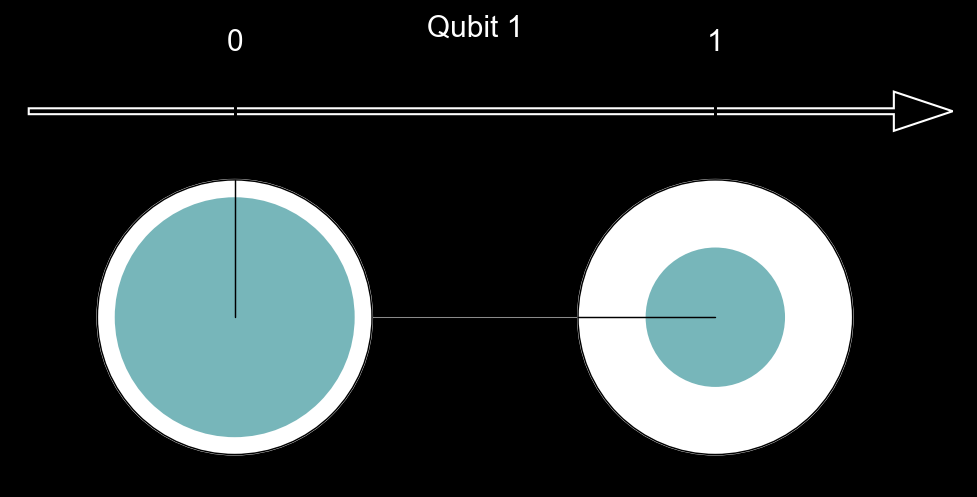

In [4]:
# Visualize using CN
DimensionalCircleNotation.from_qiskit(psi).show()

## 1.2. The Bloch sphere

We will mainly work in the circle notation in this course, because it is generalizable to systems of multiple qubits (where we work with dimensionality to gain intuition and use the dimensional circle notation (DCN)). What you will almost always encounter in quantum technology is the Bloch sphere visualization which we will discuss here shortly. The Bloch sphere does not, in general, work in multi-qubit systems, due to entanglement (see Chapter 4 and onwards). However, it visualizes qubit operations in an intuitive way and is therefore essential to gain intuition for processes in single-qubit system.

<div style="background-color: #6ab2e7; color: #042c58; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
The Bloch sphere works on the (physically true) assumption that the so-called global phase of a quantum state has no physical meaning, i.e.,

$$ |\psi\rangle \equiv e^{i\theta}|\psi\rangle.$$

This means that, given a state $|\psi\rangle = \alpha|0\rangle+\beta|1\rangle=|\alpha| e^{i\varphi_1}|0\rangle+|\beta|e^{i\varphi_2}|1\rangle$, we can write $|\psi\rangle \equiv e^{-i\varphi_1}|\psi\rangle=|\alpha||0\rangle+|\beta|e^{i(\varphi_2-\varphi_1)}|1\rangle$. We then associate $|\alpha|=\cos{(\vartheta/2)}$ and $|\beta|=\sin{(\vartheta/2)}$, as well as $\varphi=\varphi_2-\varphi_1$ to arrive at

$$|\psi\rangle=\cos{(\vartheta/2)} |0\rangle+ \sin{(\vartheta/2)}e^{i\varphi}|1\rangle.$$

We therefore can write any single-qubit state using two angles $\varphi\in[0,2\pi)$ (azimutal angle measured from the $z$-axis) and $\vartheta\in[0,\pi)$ (polar angle measured from the $x$-axis) and visualize it on a sphere like so:

</div>

In [5]:
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display

fig = plot_bloch_multivector(psi)

display(fig)
plt.close(fig)

<Figure size 480x480 with 1 Axes>

In the next notebook, we will visually discuss how such one-qubit systems are manipulated and what happens upon measurement.

## References

[1] Johnston, E. R., Harrigan, N., & Gimeno-Segovia, M. (2019). Programming quantum computers: essential algorithms and code samples. O'Reilly Media.